 # Predictive Modeling and Risk Scoring for Bank Customer Churn

**European Central Bank — Predictive Churn Intelligence System**

This notebook covers the full analytical pipeline:
1. Exploratory Data Analysis
2. Data Preprocessing & Feature Engineering
3. Model Development (Logistic Regression, Decision Tree, Random Forest, Gradient Boosting, XGBoost)
4. Model Evaluation
5. Model Explainability (Feature Importance, SHAP, Partial Dependence)
6. Key Insights & Business Recommendations

## 0. Setup

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, roc_curve, confusion_matrix, classification_report)
from sklearn.inspection import PartialDependenceDisplay
from xgboost import XGBClassifier
import shap

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
RANDOM_STATE = 42

## 1. Load Data

In [2]:
df = pd.read_csv("European_Bank.csv")
print(df.shape)
df.head()

(10000, 14)


,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Year,10000.0,NaN,NaN,NaN,2025.0,0.0,2025.0,2025.0,2025.0,2025.0,2025.0
CustomerId,10000.0,NaN,NaN,NaN,15690940.5694,71936.186123,15565701.0,15628528.25,15690738.0,15753233.75,15815690.0
Surname,10000,2932,Smith,32,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CreditScore,10000.0,NaN,NaN,NaN,650.5288,96.653299,350.0,584.0,652.0,718.0,850.0
Geography,10000,3,France,5014,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,10000,2,Male,5457,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,10000.0,NaN,NaN,NaN,38.9218,10.487806,18.0,32.0,37.0,44.0,92.0
Tenure,10000.0,NaN,NaN,NaN,5.0128,2.892174,0.0,3.0,5.0,7.0,10.0
Balance,10000.0,NaN,NaN,NaN,76485.889288,62397.405202,0.0,0.0,97198.54,127644.24,250898.09
NumOfProducts,10000.0,NaN,NaN,NaN,1.5302,0.581654,1.0,1.0,1.0,2.0,4.0


In [4]:
df.isnull().sum()

Year               0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

No missing values across all 10,000 records. The target `Exited` is imbalanced (~20% churn).

In [5]:
df["Exited"].value_counts(normalize=True)

Exited
0    0.7963
1    0.2037
Name: proportion, dtype: float64

## 2. Exploratory Data Analysis

### 2.1 Churn Distribution

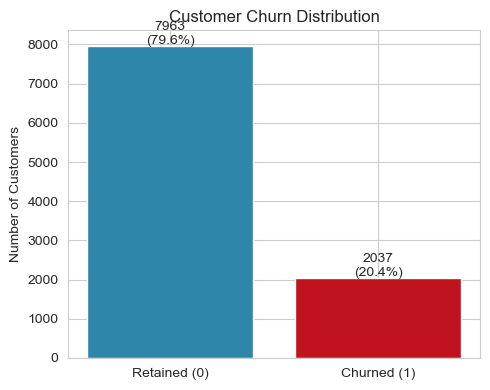

In [6]:
fig, ax = plt.subplots(figsize=(5, 4))
counts = df["Exited"].value_counts().sort_index()
ax.bar(["Retained (0)", "Churned (1)"], counts.values, color=["#2E86AB", "#C1121F"])
for i, v in enumerate(counts.values):
    ax.text(i, v + 50, f"{v}\n({v/len(df)*100:.1f}%)", ha="center")
ax.set_title("Customer Churn Distribution")
ax.set_ylabel("Number of Customers")
plt.tight_layout()
plt.show()

### 2.2 Churn by Geography and Gender

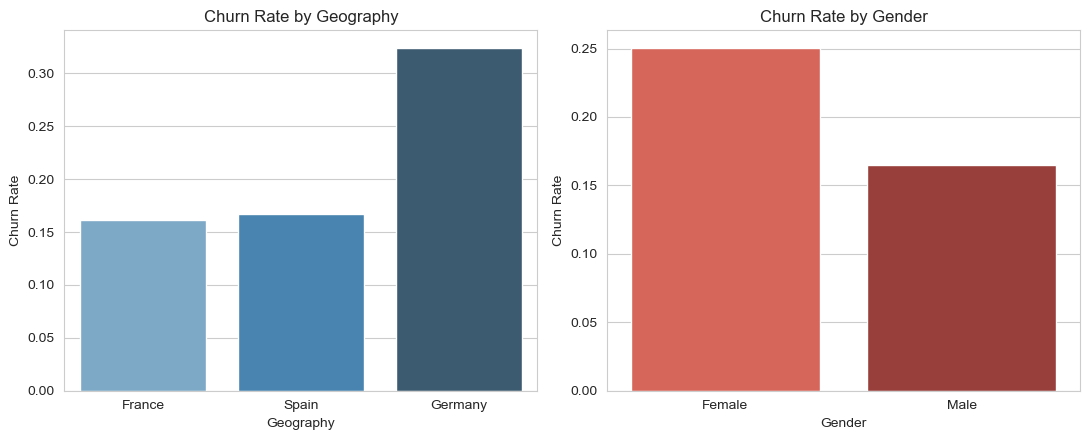

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
sns.barplot(data=df, x="Geography", y="Exited", hue="Geography", ax=axes[0], palette="Blues_d", errorbar=None, legend=False)
axes[0].set_title("Churn Rate by Geography")
axes[0].set_ylabel("Churn Rate")
sns.barplot(data=df, x="Gender", y="Exited", hue="Gender", ax=axes[1], palette="Reds_d", errorbar=None, legend=False)
axes[1].set_title("Churn Rate by Gender")
axes[1].set_ylabel("Churn Rate")
plt.tight_layout()
plt.show()

In [8]:
print("Geography churn rates:\n", df.groupby("Geography")["Exited"].mean())
print("\nGender churn rates:\n", df.groupby("Gender")["Exited"].mean())

Geography churn rates:
 Geography
France     0.161548
Germany    0.324432
Spain      0.166734
Name: Exited, dtype: float64

Gender churn rates:
 Gender
Female    0.250715
Male      0.164559
Name: Exited, dtype: float64


Germany churns at roughly double the rate of France and Spain. Female customers churn more than male customers.

### 2.3 Age Distribution

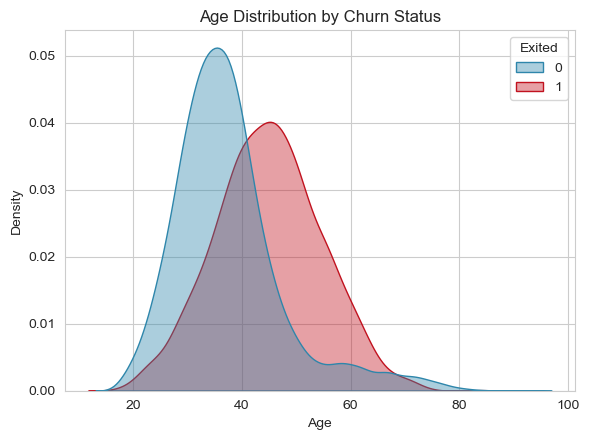

In [9]:
fig, ax = plt.subplots(figsize=(6, 4.5))
sns.kdeplot(data=df, x="Age", hue="Exited", fill=True, common_norm=False, alpha=0.4, ax=ax,
            palette={0: "#2E86AB", 1: "#C1121F"})
ax.set_title("Age Distribution by Churn Status")
plt.tight_layout()
plt.show()

### 2.4 Number of Products

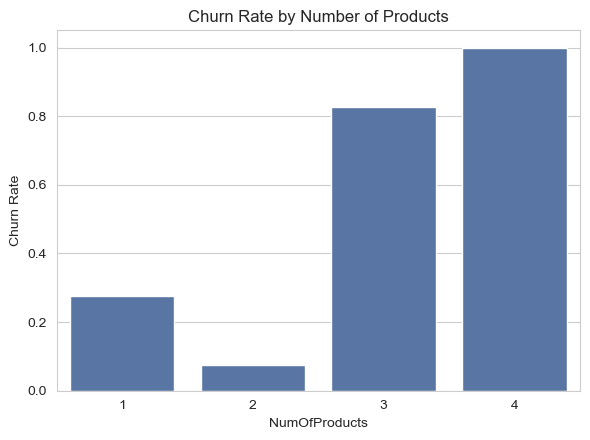

In [10]:
fig, ax = plt.subplots(figsize=(6, 4.5))
sns.barplot(data=df, x="NumOfProducts", y="Exited", ax=ax, color="#4C72B0", errorbar=None)
ax.set_title("Churn Rate by Number of Products")
ax.set_ylabel("Churn Rate")
plt.tight_layout()
plt.show()

In [11]:
df.groupby("NumOfProducts")["Exited"].mean()

NumOfProducts
1    0.277144
2    0.075817
3    0.827068
4    1.000000
Name: Exited, dtype: float64

Striking non-linear pattern: customers with 3-4 products churn at 83-100%, far above the 1-product (27.7%) and
especially the 2-product segment (7.6%, the healthiest). This points to product-fit / over-selling issues rather
than "more products = more loyalty".

### 2.5 Engagement and Credit Card Ownership

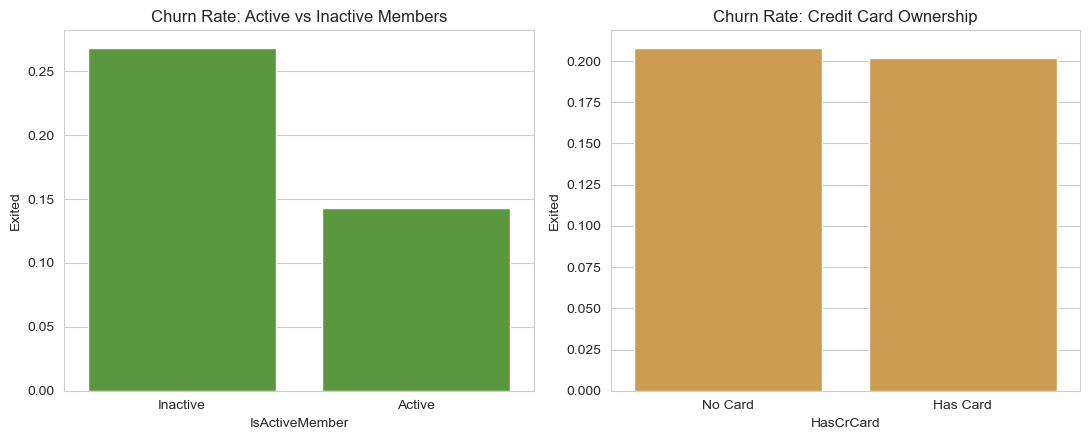

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
sns.barplot(data=df, x="IsActiveMember", y="Exited", ax=axes[0], color="#55A630", errorbar=None)
axes[0].set_title("Churn Rate: Active vs Inactive Members")
axes[0].set_xticks([0, 1]); axes[0].set_xticklabels(["Inactive", "Active"])
sns.barplot(data=df, x="HasCrCard", y="Exited", ax=axes[1], color="#E09F3E", errorbar=None)
axes[1].set_title("Churn Rate: Credit Card Ownership")
axes[1].set_xticks([0, 1]); axes[1].set_xticklabels(["No Card", "Has Card"])
plt.tight_layout()
plt.show()

In [13]:
print("Active member churn rates:\n", df.groupby("IsActiveMember")["Exited"].mean())

Active member churn rates:
 IsActiveMember
0    0.268509
1    0.142691
Name: Exited, dtype: float64


### 2.6 Account Balance

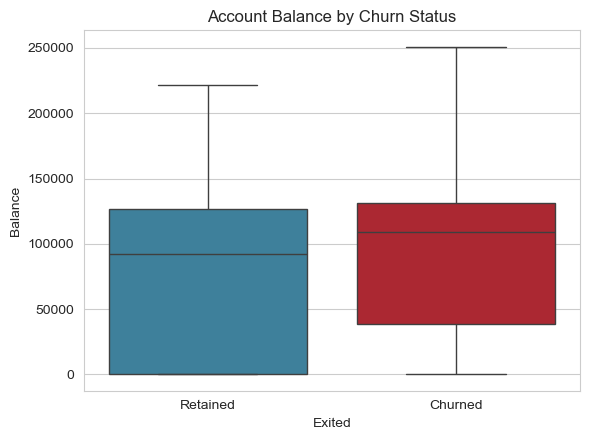

In [14]:
fig, ax = plt.subplots(figsize=(6, 4.5))
sns.boxplot(data=df, x="Exited", y="Balance", hue="Exited", ax=ax, palette={0: "#2E86AB", 1: "#C1121F"}, legend=False)
ax.set_xticks([0, 1]); ax.set_xticklabels(["Retained", "Churned"])
ax.set_title("Account Balance by Churn Status")
plt.tight_layout()
plt.show()

In [15]:
print("Zero-balance customers:", (df["Balance"] == 0).sum(), f"({(df['Balance']==0).mean()*100:.1f}%)")
print("Zero-balance churn rate:", df.loc[df["Balance"] == 0, "Exited"].mean())
print("Non-zero-balance churn rate:", df.loc[df["Balance"] > 0, "Exited"].mean())

Zero-balance customers: 3617 (36.2%)
Zero-balance churn rate: 0.13823610727121924
Non-zero-balance churn rate: 0.2407958640137866


### 2.7 Correlation Matrix

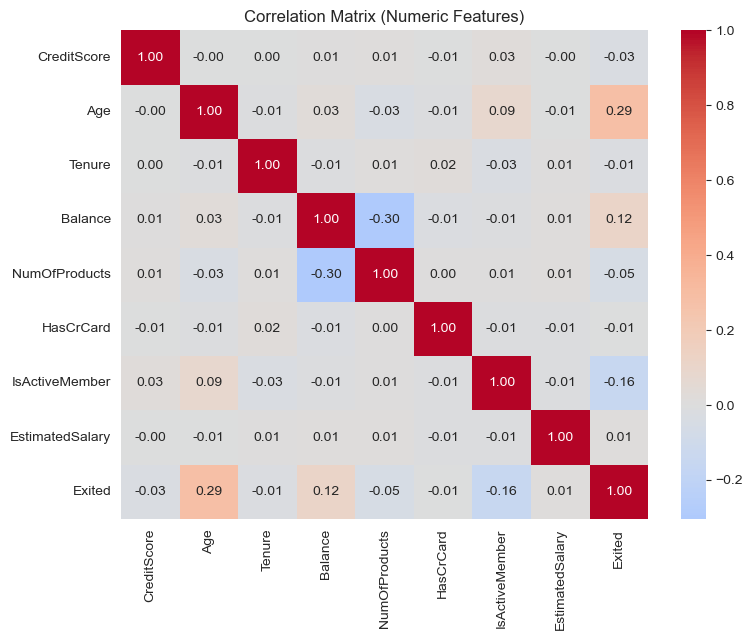

In [16]:
num_cols = ["CreditScore", "Age", "Tenure", "Balance", "NumOfProducts",
            "HasCrCard", "IsActiveMember", "EstimatedSalary", "Exited"]
fig, ax = plt.subplots(figsize=(8, 6.5))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation Matrix (Numeric Features)")
plt.tight_layout()
plt.show()

### 2.8 Tenure

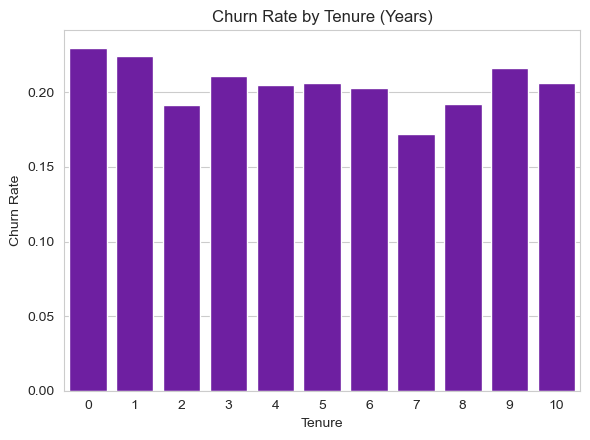

In [17]:
fig, ax = plt.subplots(figsize=(6, 4.5))
sns.barplot(data=df, x="Tenure", y="Exited", ax=ax, color="#7209B7", errorbar=None)
ax.set_title("Churn Rate by Tenure (Years)")
ax.set_ylabel("Churn Rate")
plt.tight_layout()
plt.show()

Churn rate is relatively flat across tenure — tenure alone is a weak predictor compared to engagement or product fit.

## 3. Data Preprocessing & Feature Engineering

In [18]:
model_df = df.drop(columns=["Year", "CustomerId", "Surname"])  # non-informative features

eps = 1e-6
model_df["BalanceSalaryRatio"] = model_df["Balance"] / (model_df["EstimatedSalary"] + eps)
model_df["ProductDensity"] = model_df["NumOfProducts"] / (model_df["Tenure"] + 1)
model_df["EngagementProductInteraction"] = model_df["IsActiveMember"] * model_df["NumOfProducts"]
model_df["AgeTenureInteraction"] = model_df["Age"] * model_df["Tenure"]
model_df["IsZeroBalance"] = (model_df["Balance"] == 0).astype(int)
model_df["CreditScoreBand"] = pd.cut(model_df["CreditScore"], bins=[0, 580, 670, 740, 800, 850],
                                      labels=[1, 2, 3, 4, 5]).astype(int)

# One-hot encode categoricals
model_df = pd.get_dummies(model_df, columns=["Geography", "Gender"], drop_first=True)

target = "Exited"
feature_cols = [c for c in model_df.columns if c != target]
X = model_df[feature_cols]
y = model_df[target]

print("Final feature set:", list(X.columns))
print("Shape:", X.shape)

Final feature set: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'BalanceSalaryRatio', 'ProductDensity', 'EngagementProductInteraction', 'AgeTenureInteraction', 'IsZeroBalance', 'CreditScoreBand', 'Geography_Germany', 'Geography_Spain', 'Gender_Male']
Shape: (10000, 17)


## 4. Train–Test Strategy

Stratified 80/20 split to preserve the churn class distribution, plus 5-fold stratified cross-validation
during model development.

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print(f"Train churn rate: {y_train.mean():.4f}  |  Test churn rate: {y_test.mean():.4f}")

Train churn rate: 0.2037  |  Test churn rate: 0.2035


In [20]:
numeric_features = ["CreditScore", "Age", "Tenure", "Balance", "NumOfProducts",
                     "EstimatedSalary", "BalanceSalaryRatio", "ProductDensity",
                     "EngagementProductInteraction", "AgeTenureInteraction"]
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test_scaled[numeric_features] = scaler.transform(X_test[numeric_features])

## 5. Model Development

Five models spanning interpretability to complexity: Logistic Regression (baseline), Decision Tree,
Random Forest, Gradient Boosting, and XGBoost.

In [21]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(max_depth=6, min_samples_leaf=30, class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=400, max_depth=8, min_samples_leaf=10,
                                             class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=300, max_depth=3, learning_rate=0.05,
                                                      random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(n_estimators=400, max_depth=4, learning_rate=0.05, subsample=0.8,
                              colsample_bytree=0.8, eval_metric="logloss",
                              scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
                              random_state=RANDOM_STATE, n_jobs=-1),
}

results = []
fitted_models = {}
roc_data = {}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for name, model in models.items():
    use_scaled = name == "Logistic Regression"
    Xtr = X_train_scaled if use_scaled else X_train
    Xte = X_test_scaled if use_scaled else X_test

    model.fit(Xtr, y_train)
    fitted_models[name] = model

    y_pred = model.predict(Xte)
    y_proba = model.predict_proba(Xte)[:, 1]

    cv_scores = cross_val_score(model, Xtr, y_train, cv=skf, scoring="roc_auc", n_jobs=-1)

    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
        "CV ROC-AUC (mean)": cv_scores.mean(),
        "CV ROC-AUC (std)": cv_scores.std(),
    }
    results.append(metrics)
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_data[name] = (fpr, tpr, metrics["ROC-AUC"])

    print(f"\n{'='*60}\n{name}\n{'='*60}")
    print(classification_report(y_test, y_pred, target_names=["Retained", "Churned"]))


Logistic Regression
              precision    recall  f1-score   support

    Retained       0.90      0.71      0.80      1593
     Churned       0.38      0.70      0.50       407

    accuracy                           0.71      2000
   macro avg       0.64      0.71      0.65      2000
weighted avg       0.80      0.71      0.74      2000


Decision Tree
              precision    recall  f1-score   support

    Retained       0.93      0.76      0.84      1593
     Churned       0.45      0.78      0.57       407

    accuracy                           0.76      2000
   macro avg       0.69      0.77      0.70      2000
weighted avg       0.83      0.76      0.78      2000


Random Forest
              precision    recall  f1-score   support

    Retained       0.92      0.84      0.88      1593
     Churned       0.53      0.72      0.61       407

    accuracy                           0.81      2000
   macro avg       0.73      0.78      0.75      2000
weighted avg       0.84

## 6. Model Evaluation

In [22]:
results_df = pd.DataFrame(results).sort_values("ROC-AUC", ascending=False)
results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,CV ROC-AUC (mean),CV ROC-AUC (std)
3,Gradient Boosting,0.8695,0.782946,0.496314,0.607519,0.869386,0.862854,0.009850
2,Random Forest,0.8145,0.532727,0.719902,0.612330,0.866454,0.857633,0.012265
4,XGBoost,0.8130,0.529204,0.734644,0.615226,0.862508,0.858006,0.011014
1,Decision Tree,0.7620,0.451202,0.783784,0.572711,0.842416,0.828832,0.007264
0,Logistic Regression,0.7105,0.384097,0.700246,0.496084,0.774958,0.766052,0.020307


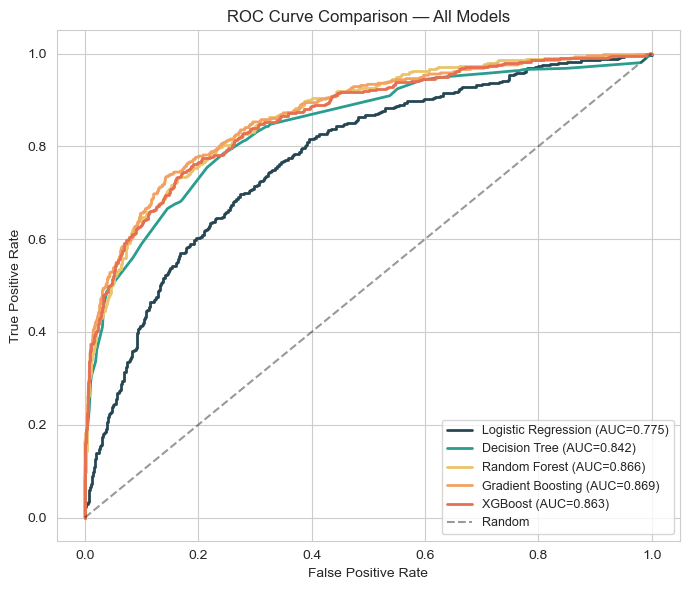

In [23]:
fig, ax = plt.subplots(figsize=(7, 6))
colors = ["#264653", "#2A9D8F", "#E9C46A", "#F4A261", "#E76F51"]
for (name, (fpr, tpr, auc)), c in zip(roc_data.items(), colors):
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})", color=c, linewidth=2)
ax.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Random")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve Comparison — All Models")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

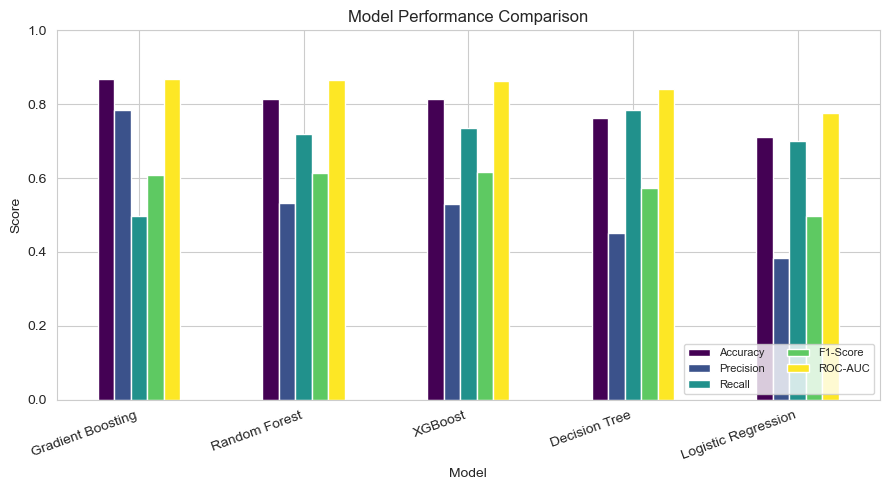

In [24]:
fig, ax = plt.subplots(figsize=(9, 5))
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
results_df.set_index("Model")[metrics_to_plot].plot(kind="bar", ax=ax, colormap="viridis")
ax.set_title("Model Performance Comparison"); ax.set_ylabel("Score"); ax.set_ylim(0, 1)
ax.legend(loc="lower right", ncol=2, fontsize=8)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

### Best Model — Confusion Matrix

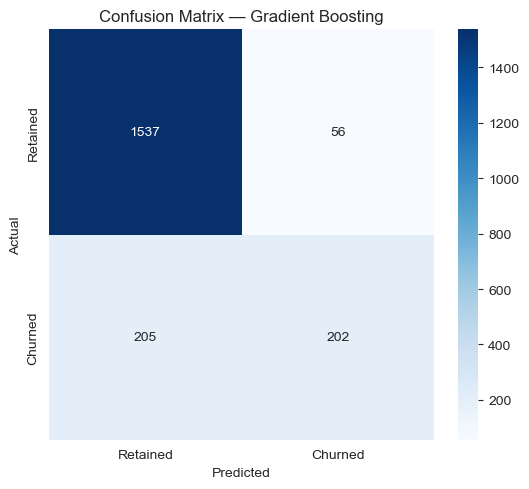

BEST MODEL: Gradient Boosting  |  ROC-AUC: 0.8694


In [25]:
best_model_name = results_df.iloc[0]["Model"]
best_model = fitted_models[best_model_name]
use_scaled = best_model_name == "Logistic Regression"
Xte_best = X_test_scaled if use_scaled else X_test
y_pred_best = best_model.predict(Xte_best)

cm = confusion_matrix(y_test, y_pred_best)
fig, ax = plt.subplots(figsize=(5.5, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=["Retained", "Churned"], yticklabels=["Retained", "Churned"])
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title(f"Confusion Matrix — {best_model_name}")
plt.tight_layout()
plt.show()

print(f"BEST MODEL: {best_model_name}  |  ROC-AUC: {results_df.iloc[0]['ROC-AUC']:.4f}")

## 7. Model Explainability

### 7.1 Feature Importance

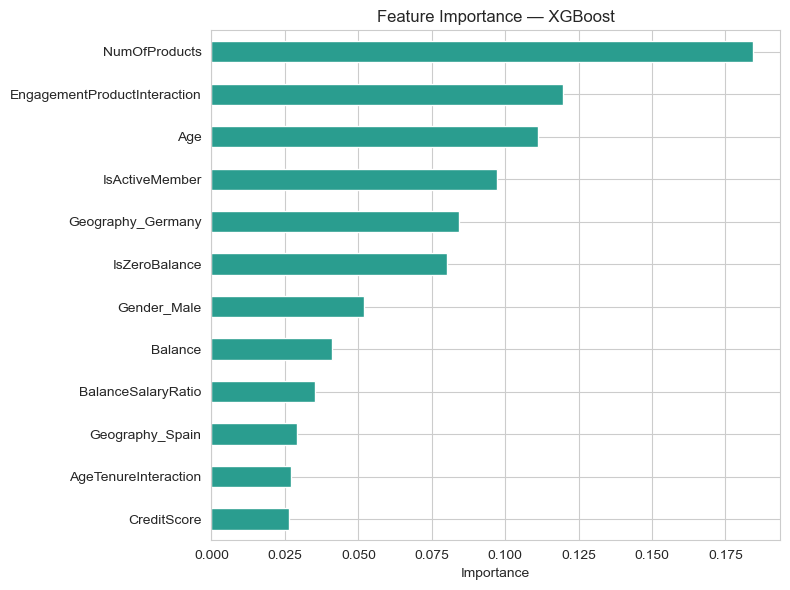

NumOfProducts                   0.184365
EngagementProductInteraction    0.119783
Age                             0.111208
IsActiveMember                  0.097252
Geography_Germany               0.084389
IsZeroBalance                   0.080033
Gender_Male                     0.051811
Balance                         0.041209
BalanceSalaryRatio              0.035211
Geography_Spain                 0.028975
dtype: float32

In [26]:
importance_model_name = "XGBoost" if "XGBoost" in fitted_models else best_model_name
imp_model = fitted_models[importance_model_name]
importances = pd.Series(imp_model.feature_importances_, index=X.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
importances.head(12).sort_values().plot(kind="barh", ax=ax, color="#2A9D8F")
ax.set_title(f"Feature Importance — {importance_model_name}"); ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

importances.head(10)

### 7.2 SHAP Analysis

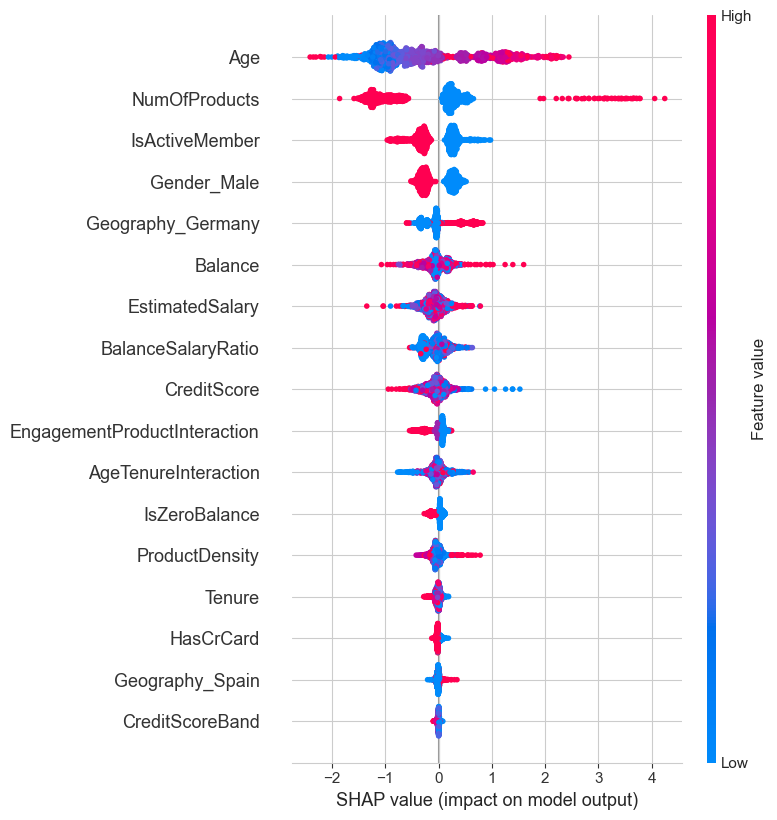

In [27]:
X_sample = X_train.sample(n=min(1500, len(X_train)), random_state=42)
explainer = shap.TreeExplainer(fitted_models["XGBoost"])
shap_values = explainer(X_sample)

shap.summary_plot(shap_values, X_sample, show=True)

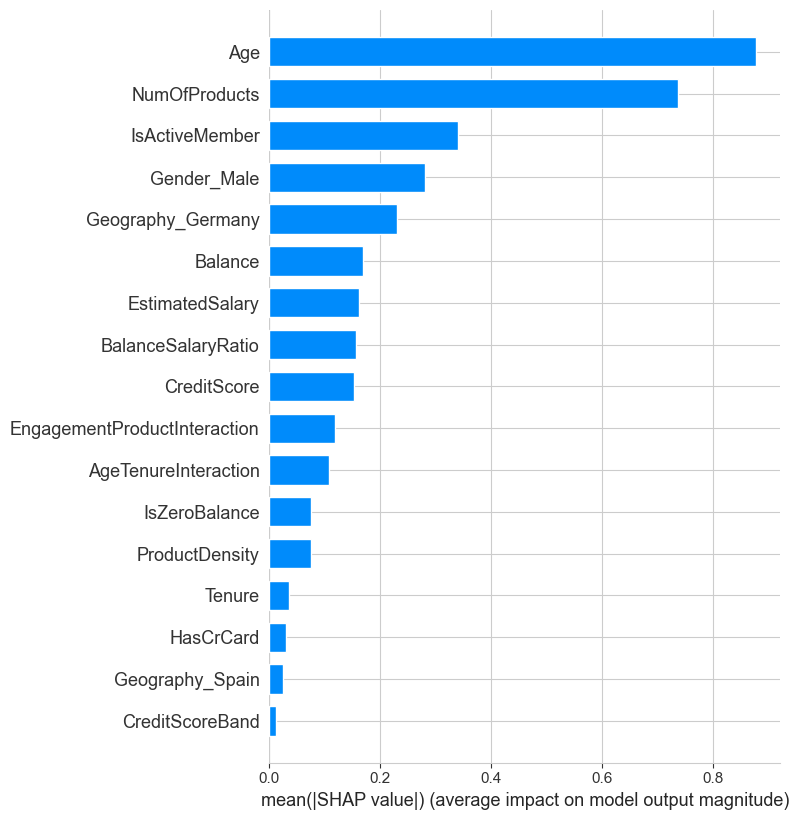

In [28]:
shap.summary_plot(shap_values, X_sample, plot_type="bar", show=True)

### 7.3 Partial Dependence Plots

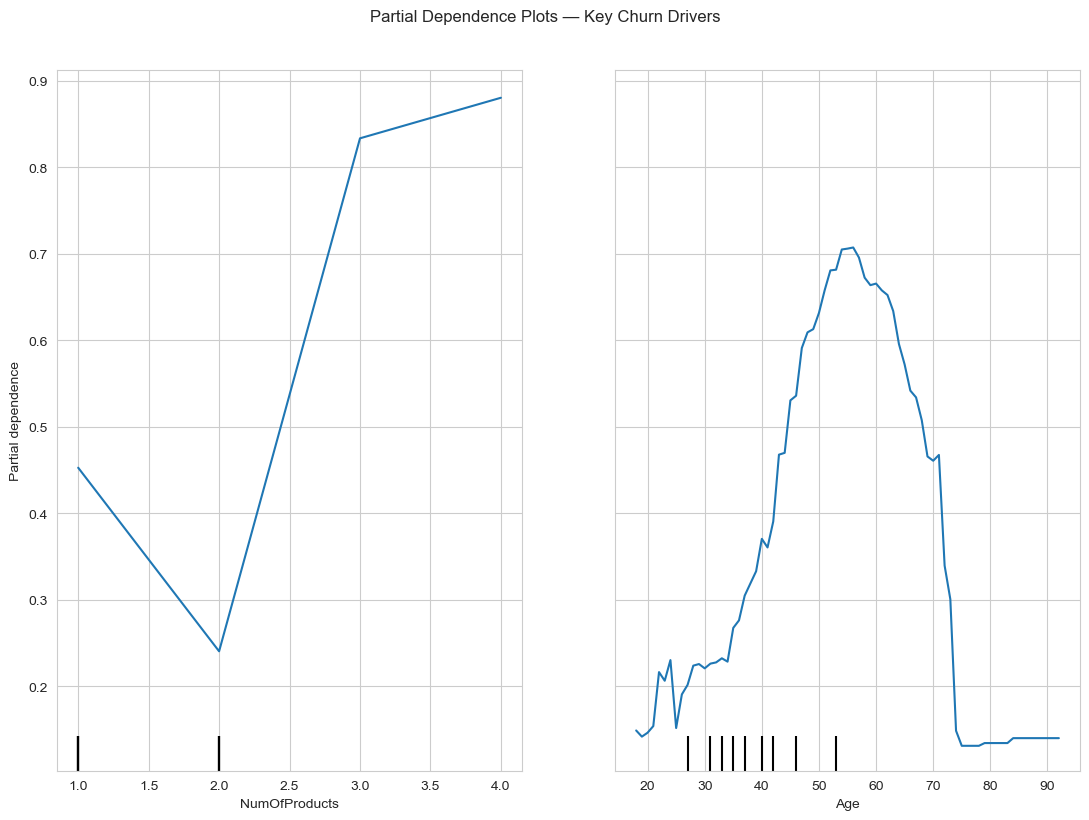

In [29]:
key_features = ["NumOfProducts", "Age"]
fig, ax = plt.subplots(figsize=(11, 8))
PartialDependenceDisplay.from_estimator(fitted_models["XGBoost"], X_train, key_features, ax=ax, n_cols=2)
fig.suptitle("Partial Dependence Plots — Key Churn Drivers", y=1.02)
plt.tight_layout()
plt.show()

## 8. Key Insights

- **Product over-holding** is the single largest churn driver: 3+ products → 83-100% churn vs. 7.6% at 2 products.
- **Engagement** matters more than demographics: inactive members churn at ~2x the rate of active members.
- **Germany** is a structurally higher-risk market (32.4% churn vs. ~16% in France/Spain).
- **Age** shows a steady, positive association with churn risk.
- **Tenure** alone is a weak predictor — relationship length doesn't guarantee loyalty without engagement.

## 9. Business Recommendations

1. Trigger priority retention outreach for customers scoring above the high-risk threshold.
2. Investigate the 3-4 product segment as a product-fit / cross-sell process issue.
3. Launch a Germany-specific retention and competitive review.
4. Prioritize engagement-activation campaigns for inactive members.
5. Use scenario simulation to quantify expected risk reduction of interventions before committing budget.

## 10. Save Model Artifacts (for the Streamlit app)

In [30]:
import os
os.makedirs("models", exist_ok=True)

joblib.dump(best_model, "models/best_model.pkl")
joblib.dump(fitted_models["XGBoost"], "models/xgboost_model.pkl")
joblib.dump(fitted_models["Logistic Regression"], "models/logreg_model.pkl")
joblib.dump(scaler, "models/scaler.pkl")
joblib.dump(list(X.columns), "models/feature_columns.pkl")
joblib.dump(numeric_features, "models/numeric_features.pkl")

meta = {
    "best_model_name": best_model_name,
    "importance_model_name": importance_model_name,
    "feature_columns": list(X.columns),
    "numeric_features": numeric_features,
    "results": results_df.to_dict(orient="records"),
    "top_features": importances.head(10).to_dict(),
}
with open("models/meta.json", "w") as f:
    json.dump(meta, f, indent=2, default=str)

X_train.assign(Exited=y_train).to_csv("models/train_reference.csv", index=False)
mean_abs_shap = pd.Series(np.abs(shap_values.values).mean(axis=0), index=list(X_sample.columns)).sort_values(ascending=False)
mean_abs_shap.to_csv("models/shap_importance.csv", header=["mean_abs_shap"])

print("All artifacts saved to models/")

All artifacts saved to models/


In [31]:
import subprocess
process = subprocess.Popen(["streamlit", "run", "app.py", "--server.port", "8501"])
print("Streamlit running → open http://localhost:8501 in your browser")
# To stop later: process.terminate()

Streamlit running → open http://localhost:8501 in your browser
